In [3]:
# 21-08-2026
#CLASS-WORK ON MACHINE LEARNING USING LOAN_DEFAULT DATASET

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load Historical Data
loan= pd.read_csv('loan_defaults.csv')
print('Dataset shape:', loan.shape)
print()
loan.head(8)



Dataset shape: (150, 4)



,income,debt_ratio,num_late_payments,defaulted
0,877933,0.25,3,0
1,292175,0.20,1,0
2,346524,0.43,8,1
3,289362,0.17,10,1
4,42544,0.73,0,1
5,561299,0.19,3,0
6,571958,0.85,6,0
7,377098,0.14,8,1


In [4]:
# separing the features (X) from the Label (y)
X = loan[['income', 'debt_ratio', 'num_late_payments']]
y = loan['defaulted']
print('Features (X) - 3 columns, 150 rows:')
print(X.head(3))
print()
print('Label (y) - what we want to predict:')
print(y.values)
print(f'defaulted: {y.sum()} | Fulfilled: {(y==0).sum()}')


Features (X) - 3 columns, 150 rows:
   income  debt_ratio  num_late_payments
0  877933        0.25                  3
1  292175        0.20                  1
2  346524        0.43                  8

Label (y) - what we want to predict:
[0 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 0 1 1 0 1 0
 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1
 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 0
 1 1 1 1 1 0 0 0 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 0
 1 1]
defaulted: 104 | Fulfilled: 46


In [5]:
# Spliting for model training: 90% for training, 10% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(f'Training set: {len(X_train)} income')
print(f'Test set:     {len(X_test)} income')
print()

# Train the ML model - it learns the rules from training data
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)   # <-- this is where learning happens

print('Model trained. It has now seen', len(X_train), 'examples.')
print('It learned patterns - no rules were written by hand.')

Training set: 135 income
Test set:     15 income

Model trained. It has now seen 135 examples.
It learned patterns - no rules were written by hand.


In [9]:
# Evaluating the test set - applicants the model has NEVER seen
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print('Test set predictions vs actual decisions:')
print(f'{"Actual":<10} {"ML Predicted":<15} {"Match?"}')
print('*' * 35)
for actual, predicted in zip(y_test, y_pred):
    match = 'YES' if actual == predicted else 'NO'
    label_a = 'DEFAULTED' if actual    else 'FULFILLED'
    label_p = 'DEFAULTED' if predicted else 'FULFILLED'
    print(f'{label_a:<10} {label_p:<15} {match}')

print()
print(f'Accuracy: {accuracy*100:.0f}%')
print('*' * 35)

Test set predictions vs actual decisions:
Actual     ML Predicted    Match?
***********************************
DEFAULTED  DEFAULTED       YES
DEFAULTED  DEFAULTED       YES
FULFILLED  DEFAULTED       NO
FULFILLED  FULFILLED       YES
DEFAULTED  FULFILLED       NO
FULFILLED  FULFILLED       YES
FULFILLED  FULFILLED       YES
DEFAULTED  DEFAULTED       YES
DEFAULTED  FULFILLED       NO
DEFAULTED  DEFAULTED       YES
FULFILLED  FULFILLED       YES
DEFAULTED  FULFILLED       NO
FULFILLED  DEFAULTED       NO
DEFAULTED  DEFAULTED       YES
FULFILLED  DEFAULTED       NO

Accuracy: 60%
***********************************


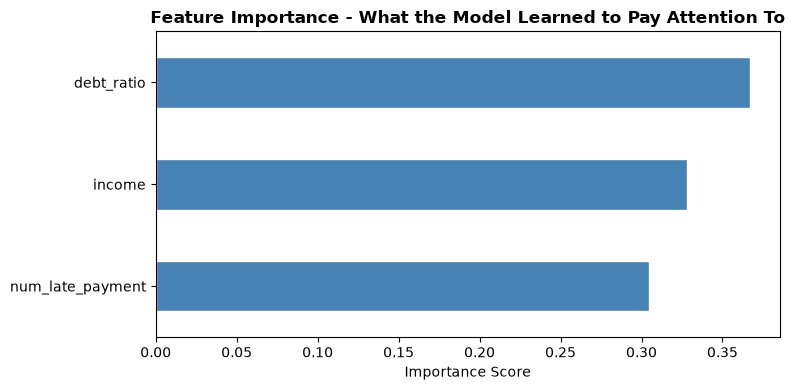

The model assigned importance to each feature based on the training data.
This is the pattern it learned - no human specified these weights.


In [8]:
# VISUALIZATION OF LOAN_DEFAULTS.CSV

loan - pd.read_csv('loan_defaults.csv')
import matplotlib.pyplot as plt

# Feature importance - which feature mattered most to the model?
importance = pd.Series(
    model.feature_importances_,
    index=['income', 'debt_ratio', 'num_late_payment']
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance - What the Model Learned to Pay Attention To',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('The model assigned importance to each feature based on the training data.')
print('This is the pattern it learned - no human specified these weights.')